In [ ]:
# ============================================================
# SCHRITT 1: Pakete installieren
# ============================================================
!pip install pyiqa torch torchvision pillow pandas tqdm matplotlib -q
print('✅ Pakete installiert')

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 42.2 MB/s eta 0:00:00
✅ Pakete installiert


In [ ]:
# ============================================================
# SCHRITT 2: Google Drive verbinden
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive verbunden')

Mounted at /content/drive
✅ Google Drive verbunden


In [ ]:
# ============================================================
# SCHRITT 3: Pfade konfigurieren
# ============================================================
import os

IMAGE_FOLDER = '/content/drive/MyDrive/flickr_data_subset/subset/outdoor'
OUTPUT_CSV = '/content/drive/MyDrive/flickr_data_subset/subset/clipiqa_scores.csv'

SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

image_paths = [
    os.path.join(IMAGE_FOLDER, f)
    for f in os.listdir(IMAGE_FOLDER)
    if f.endswith(SUPPORTED_FORMATS)
]

print(f'✅ {len(image_paths)} Bilder gefunden')
print('Erste 5:', image_paths[:5])

✅ 897 Bilder gefunden
Erste 5: ['/content/drive/MyDrive/flickr_data_subset/subset/outdoor/image_44.jpg', '/content/drive/MyDrive/flickr_data_subset/subset/outdoor/image_51.jpg', '/content/drive/MyDrive/flickr_data_subset/subset/outdoor/image_53.jpg', '/content/drive/MyDrive/flickr_data_subset/subset/outdoor/image_52.jpg', '/content/drive/MyDrive/flickr_data_subset/subset/outdoor/image_56.jpg']


In [ ]:
# ============================================================
# SCHRITT 4: CLIP-IQA Modell laden
# Gewichte werden automatisch heruntergeladen – kein manueller Download!
# ============================================================
import pyiqa
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Verwende Gerät: {device}')

# CLIP-IQA+ ist die verbesserte Version (empfohlen)
clipiqa_model = pyiqa.create_metric('clipiqa+', device=device)
print('✅ CLIP-IQA+ Modell geladen (Gewichte automatisch heruntergeladen)')

Verwende Gerät: cuda


100%|████████████████████████████████████████| 244M/244M [00:01<00:00, 176MiB/s]


Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/CLIP-IQA%2B_learned_prompts-603f3273.pth" to /root/.cache/torch/hub/pyiqa/CLIP-IQA%2B_learned_prompts-603f3273.pth



100%|██████████| 16.7k/16.7k [00:00<00:00, 61.0MB/s]


✅ CLIP-IQA+ Modell geladen (Gewichte automatisch heruntergeladen)


In [ ]:
# ============================================================
# SCHRITT 5: Hilfsfunktion
# ============================================================
from PIL import Image
import pandas as pd
from tqdm import tqdm

def score_image_clipiqa(image_path):
    """Berechnet CLIP-IQA+ Score für ein einzelnes Bild."""
    try:
        score = clipiqa_model(image_path)
        return float(score.item()), None
    except Exception as e:
        return None, str(e)

print('✅ Hilfsfunktion definiert')

✅ Hilfsfunktion definiert


In [ ]:
# ============================================================
# SCHRITT 6: Alle Bilder bewerten
# ============================================================
results = []
errors = []

print(f'Bewerte {len(image_paths)} Bilder mit CLIP-IQA+...')

for img_path in tqdm(image_paths):
    filename = os.path.basename(img_path)
    score, error = score_image_clipiqa(img_path)

    if error:
        errors.append({'filename': filename, 'error': error})
    else:
        results.append({
            'filename': filename,
            'filepath': img_path,
            'clipiqa_score': round(score, 4)
        })

print(f'\n✅ {len(results)} Bilder bewertet')
print(f'⚠️  {len(errors)} Fehler')

Bewerte 897 Bilder mit CLIP-IQA+...


100%|██████████| 897/897 [22:27<00:00,  1.50s/it]


✅ 890 Bilder bewertet
⚠️  7 Fehler


In [ ]:
# ============================================================
# SCHRITT 7: Ergebnisse anzeigen und speichern
# ============================================================
df = pd.DataFrame(results)
df = df.sort_values('clipiqa_score', ascending=False).reset_index(drop=True)

print('=== CLIP-IQA+ Score Statistiken ===')
print(f'Anzahl Bilder:     {len(df)}')
print(f'Mittlerer Score:   {df["clipiqa_score"].mean():.4f}')
print(f'Min Score:         {df["clipiqa_score"].min():.4f}')
print(f'Max Score:         {df["clipiqa_score"].max():.4f}')
print(f'Std:               {df["clipiqa_score"].std():.4f}')
print()
print('=== Top 10 ===')
print(df[['filename', 'clipiqa_score']].head(10).to_string())

df.to_csv(OUTPUT_CSV, index=False)
print(f'\n✅ CSV gespeichert: {OUTPUT_CSV}')

=== CLIP-IQA+ Score Statistiken ===
Anzahl Bilder:     890
Mittlerer Score:   0.5674
Min Score:         0.2497
Max Score:         0.8286
Std:               0.0985

=== Top 10 ===
          filename  clipiqa_score
0    image_127.jpg         0.8286
1    image_132.jpg         0.8199
2    image_124.jpg         0.8145
3   image_1005.jpg         0.8063
4     image_71.jpg         0.8048
5  image_11115.jpg         0.8009
6   image_1087.jpg         0.7994
7     image_53.jpg         0.7881
8    image_130.jpg         0.7819
9   image_1239.jpg         0.7807

✅ CSV gespeichert: /content/drive/MyDrive/flickr_data_subset/subset/clipiqa_scores.csv


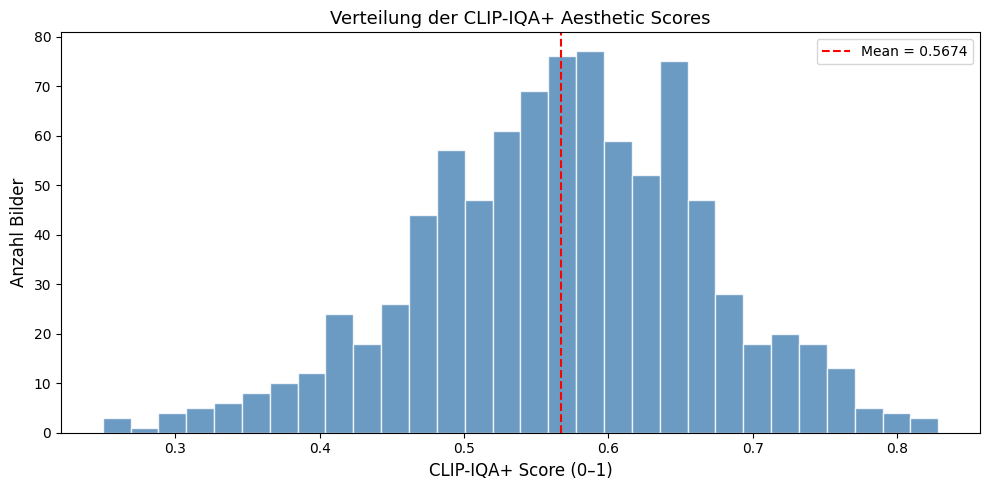

✅ Plot gespeichert


In [ ]:
# ============================================================
# SCHRITT 8: Score-Verteilung visualisieren
# ============================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['clipiqa_score'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(df['clipiqa_score'].mean(), color='red', linestyle='--',
           label=f'Mean = {df["clipiqa_score"].mean():.4f}')
ax.set_xlabel('CLIP-IQA+ Score (0–1)', fontsize=12)
ax.set_ylabel('Anzahl Bilder', fontsize=12)
ax.set_title('Verteilung der CLIP-IQA+ Aesthetic Scores', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/flickr_data_subset/subset/clipiqa_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot gespeichert')

/tmp/ipykernel_3434/605314788.py:27: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


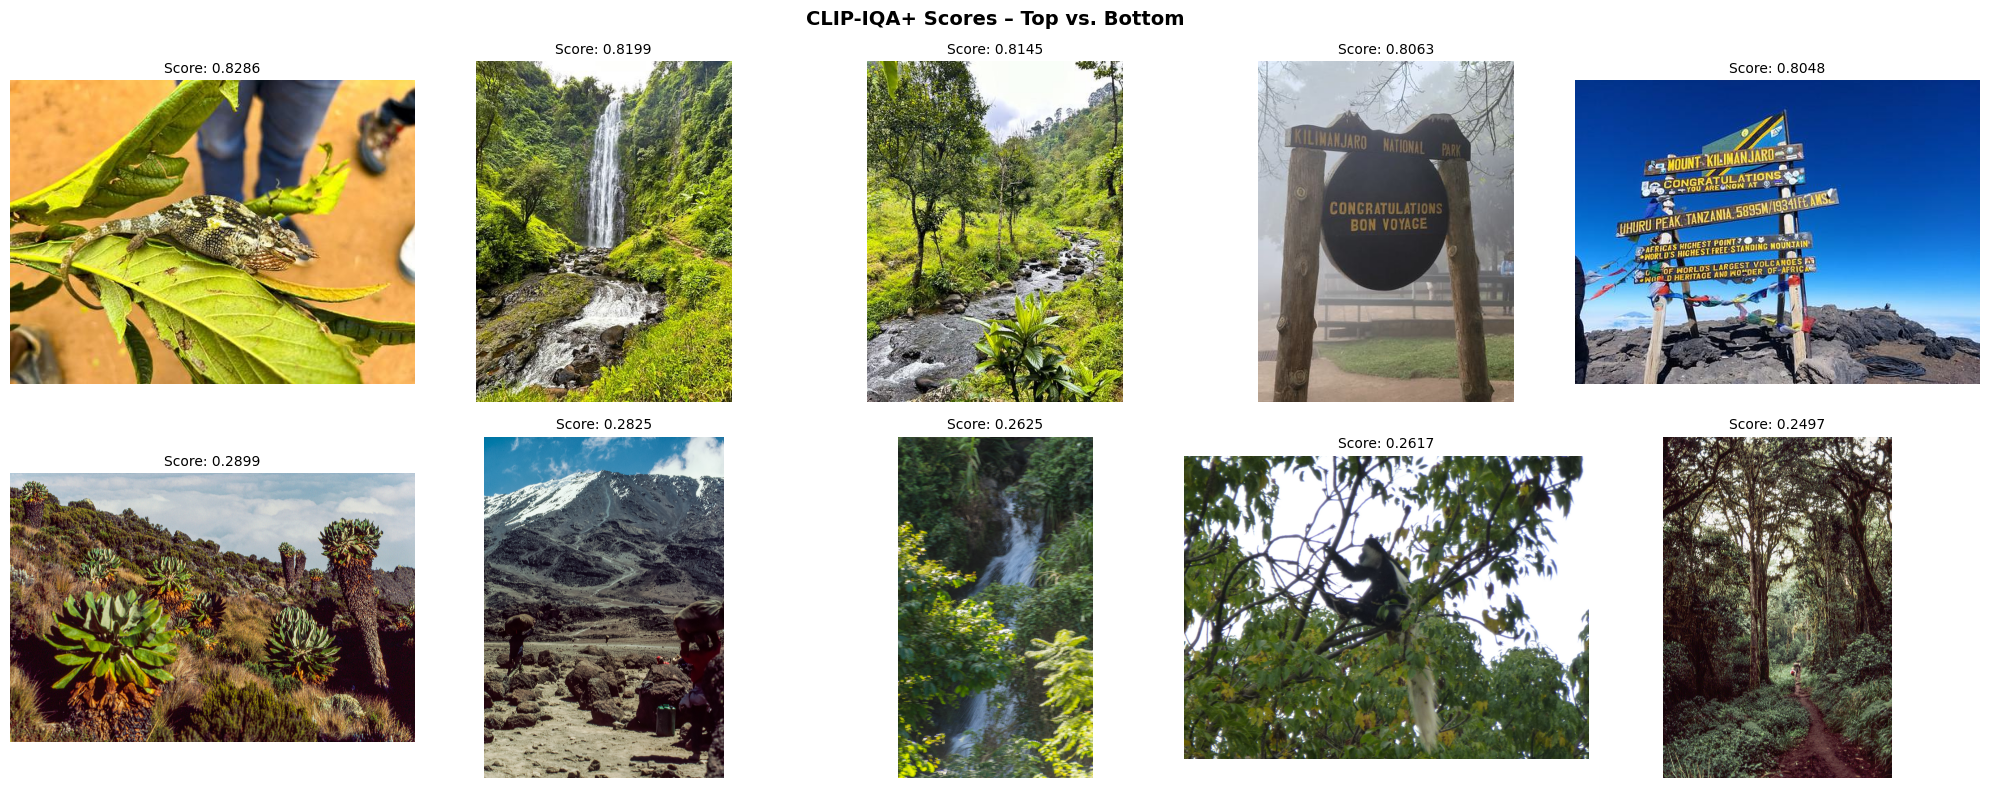

In [ ]:
# ============================================================
# SCHRITT 9 (Optional): Top und Bottom Bilder anzeigen
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (_, row) in enumerate(df.head(5).iterrows()):
    try:
        img = Image.open(row['filepath']).convert('RGB')
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Score: {row["clipiqa_score"]:.4f}', fontsize=10)
        axes[0, i].axis('off')
    except:
        axes[0, i].axis('off')

for i, (_, row) in enumerate(df.tail(5).iterrows()):
    try:
        img = Image.open(row['filepath']).convert('RGB')
        axes[1, i].imshow(img)
        axes[1, i].set_title(f'Score: {row["clipiqa_score"]:.4f}', fontsize=10)
        axes[1, i].axis('off')
    except:
        axes[1, i].axis('off')

axes[0, 0].set_ylabel('🌟 Top 5', fontsize=12, rotation=0, labelpad=60)
axes[1, 0].set_ylabel('⬇️ Bottom 5', fontsize=12, rotation=0, labelpad=60)
plt.suptitle('CLIP-IQA+ Scores – Top vs. Bottom', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()